# <center> Cluster Modelling (Multi-Method) <br> Salary and Spending Scores Example</center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

There are over 100 different clustering algorithms! In this notebook, we'll look at 5 of the most common methods!
We can break the methods down into:

1. Divisive Methods
   - K-Means Clustering
   - K-Medoids Clustering (a variation of K-Means)
   - Density Based Clustering (DBSCAN)
2. Agglomerative Clustering
   - Hierarchial Clustering (Agglomerative Clustering)
   - Dendograms
   - Mean Shift Clustering

Some additional References:
<br>https://www.ijser.org/researchpaper/Importance-of-Clustering-in-Data-Mining.pdf
https://www.forbes.com/2010/07/26/cluster-analysis-predictions-technology-social-media.html#530e84232234

---
In this Sample Notebook, we have an estimated annual income and a spending score for a shopping centre. <br>How can we group these customers/clients?

## Import Libraries

In [3]:
# Just to ignore warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle as pickle

# Clustering Evaluation Metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

## Determine, Load and Review Dataset

In [5]:
df = pd.read_csv('spending.csv')

In [6]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.2 KB


In [8]:
df.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


Text(0, 0.5, 'Spending Score (1-100)')

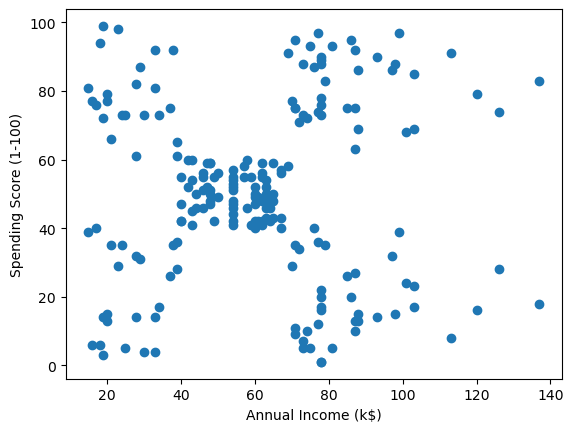

In [9]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

## Define training data 

Because there are no labels, all values are used as we would like all data points clustered for future consideration in whatever workflow we are creating.

In [11]:
x_columns = 2
x = df.iloc[:, 0:x_columns].values

## K-Means Cluster Model (Review)

In [13]:
# Create the model with a number that might make sense based on the visualization
from sklearn.cluster import KMeans
model = KMeans(n_clusters=5, random_state=0)

In [15]:
# What are we predicting with this model?
## The number used to count off which objects belong in the same group!

y = model.fit_predict(x)
print(y)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


In [16]:
# Determine the Centroids for visualization
# (The output is the set of coordinates that we can use to visualize the centroid.)

centres=model.cluster_centers_
print(centres)

[[88.2        17.11428571]
 [55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [26.30434783 20.91304348]]


Text(0, 0.5, 'Spending Score (1-100)')

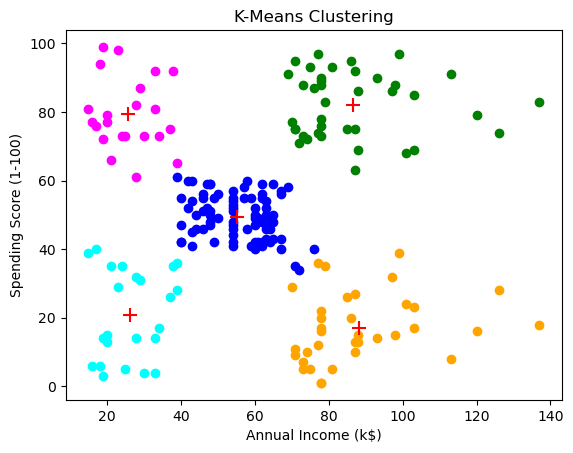

In [17]:
import matplotlib.pyplot as plt
colors = ['orange', 'blue', 'green', 'magenta', 'cyan']
for i in range(5):
    plt.scatter(x[y == i, 0], x[y == i, 1], c=colors[i])
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], color='red', marker='+', s=100)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)'), plt.ylabel('Spending Score (1-100)')

#### Optimize the K-Means Model

Text(0, 0.5, 'SSE')

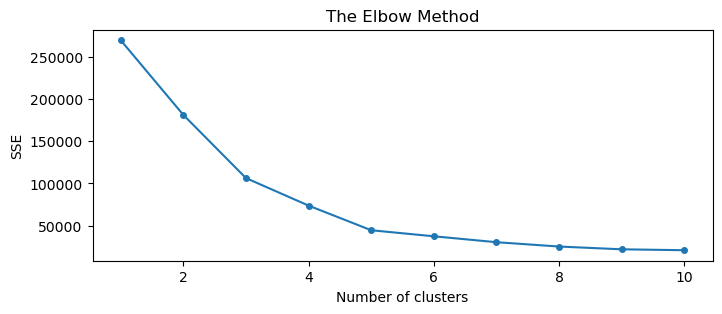

In [75]:
from sklearn.cluster import KMeans
scores = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=0)
    model.fit(x)
    scores.append(model.inertia_)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,3))
plt.plot(range(1, 11), scores, marker='.', markersize=8)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE') # Model Inertia

In [20]:
model5 = KMeans(n_clusters=5, random_state=0)
y5 = model5.fit_predict(x)
centres5 = model5.cluster_centers_

labels = model5.labels_
print("Inertia:", round(model5.inertia_,2))
print("Silhouette Score:", round(silhouette_score(x, labels),2))

Inertia: 44448.46
Silhouette Score: 0.55


Text(0, 0.5, 'Inertia')

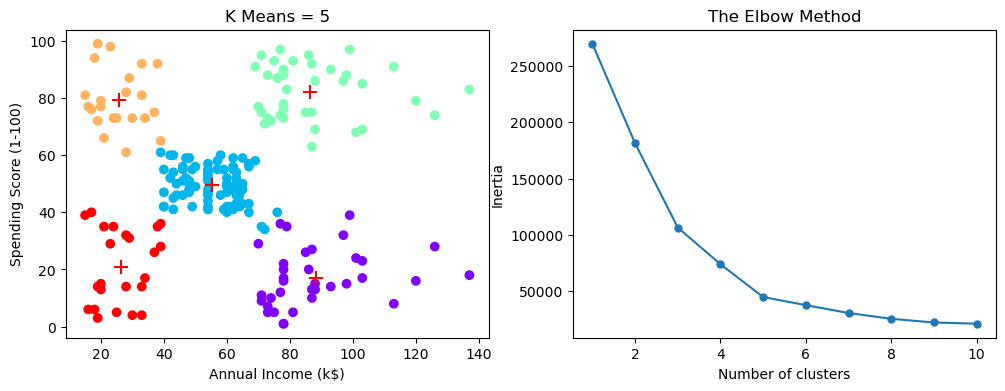

In [54]:
f, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,4))

ax1.set_title('K Means = 5')
ax1.scatter(x[:,0],x[:,1],c=model5.labels_,cmap='rainbow')
ax1.scatter(model5.cluster_centers_[:, 0], model5.cluster_centers_[:, 1], color='red', marker='+', s=100)
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')


ax2.set_title('The Elbow Method')
ax2.plot(range(1, 11), scores, marker = '.',markersize=10)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Inertia')

## K-Mediods
An alternative to K-means (which uses the average as the centre point), K-mediods forces the centroid to be one of the data points. The advantage is it becomes less sensitive to outliers and often performs better on noisy, non-spherical clusters.

This is outside the scope of the course, but you can find more info here! https://pypi.org/project/scikit-learn-extra/

Can use pip to install and try the algorithm if you wish:

In [23]:
#pip install scikit-learn-extra

Final K-Mediods Centroids:
[[28. 82.]
 [40. 42.]
 [60. 49.]
 [79. 83.]
 [88. 15.]]


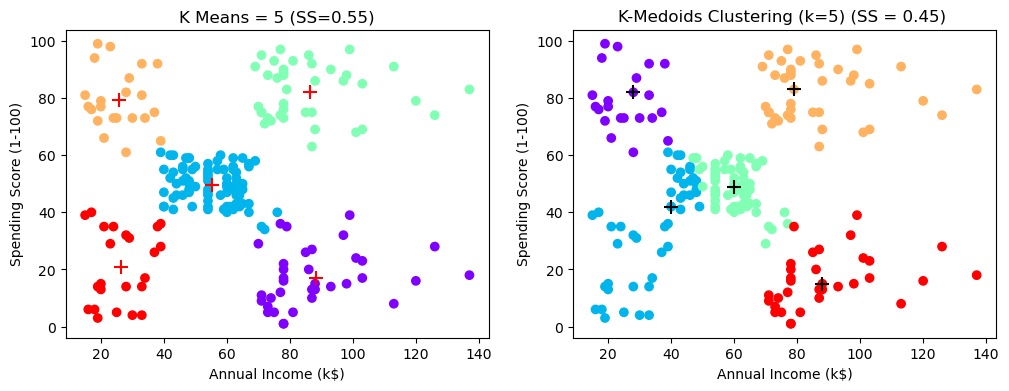

In [147]:
from sklearn_extra.cluster import KMedoids

model_mediods = KMedoids(n_clusters=5, random_state=0)
y_mediods = model_mediods.fit_predict(x)
centres_mediods = model_mediods.cluster_centers_
print("Final K-Mediods Centroids:")
print(centres)


f, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,4))
colors = ['orange', 'blue', 'green', 'magenta', 'cyan', 'yellow']

ax1.set_title(f'K Means = 5 (SS={round(silhouette_score(x, model5.labels_),2)})')
ax1.scatter(x[:,0],x[:,1],c=model5.labels_,cmap='rainbow')
ax1.scatter(model5.cluster_centers_[:, 0], model5.cluster_centers_[:, 1], color='red', marker='+', s=100)
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')

ax2.set_title(F'K-Medoids Clustering (k=5) (SS = {round(silhouette_score(x, model_mediods.labels_),2)}) ')
ax2.scatter(x[:,0],x[:,1],c=model_mediods.labels_,cmap='rainbow')
ax2.scatter(model_mediods.cluster_centers_[:, 0], model_mediods.cluster_centers_[:, 1], color='black', marker='+', s=100)
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')
plt.show()

## Additional Clustering Methods:

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise) 

An algorithm available in scikit-learn that clusters "close" points (based on a distance measurement -usually Euclidean distance) and that requires a minimum number of points to form a cluster.

<br>Positives - Don't have to define the number of clusters at the beginning, allows labelling outliers, can set min. group size. Shape can be arbitrary.
<br>Drawbacks - Can have unlabelled points, sensitive to the distance and cluster size, and can underperform when clusters overlap/vary in intra-cluster density.

- eps = the maximum radius (distance) to consider when finding points to join into a cluster
- min_samples = the fewest number of points required to allow the start of a new cluster, and not classify as an outlier
- metric = the distance measure caculation used, default is 'euclidean'

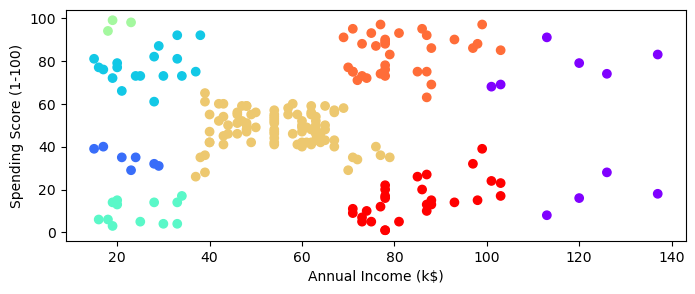

Number of clusters: 7
[ 0  1  2  1  0  1  2  3  2  1  2  3  2  1  2  1  0  1  0  3  0  1  2  1
  2  1  0  1  0  1  2  1  2  1  2  1  2  1  4  1  4  1  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  5  4  5  4  5  6  5  6  5  4  5  6  5  6  5  6  5  6  5  4  5
  6  5  4  5  6  5  6  5  6  5  6  5  6  5  6  5  4  5  6  5  6  5  6  5
  6  5  6  5  6  5  6  5  6  5  6  5  6  5  6  5  6  5  6 -1  6  5  6 -1
 -1 -1 -1 -1 -1 -1 -1 -1]
SS = 0.48


In [183]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 9.25, min_samples = 3, metric = "euclidean")
clusters = dbscan.fit_predict(x)

# plot the cluster assignments
plt.figure(figsize=(8,3))
plt.scatter(x[:, 0], x[:, 1], c=clusters, cmap="rainbow")
plt.xlabel('Annual Income (k$)'), plt.ylabel('Spending Score (1-100)')
plt.show()

# Clusters labelled -1 are not in any specific group i.e. outliers
print("Number of clusters:", len(np.unique(clusters))-1)
print(clusters)
print('SS =', round(silhouette_score(x, dbscan.labels_),2))

*Please note:* 
- The Hyperparameter 'eps' is the maximum distance between two samples for one to be considered as in the neighborhood of the other. This is entirely dependent on your specific data values so you will need to adjust this to meet your needs specifically for your model. You can automate this 'guess' for high-dimensional or unfamiliar data if you wish, using an Elbow Plot method on a k-distance plot. (Outside the scope of the course, but good to know!)

Reference: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Hierarchial Clustering

There are two top-level methods for finding these hierarchical clusters:

#### Agglomerative Clustering
Agglomerative clustering uses a bottom-up approach, wherein each data point starts in its own cluster. These clusters are then joined greedily, by taking the two most similar clusters together and merging them.
<br>Divisive clustering uses a top-down approach, wherein all data points start in the same cluster. You can then use a parametric clustering algorithm like K-Means to divide the cluster into two clusters. For each cluster, you further divide it down to two clusters until you hit the desired number of clusters.
Both of these approaches rely on constructing a similarity matrix between all of the data points, which is usually calculated by cosine or Jaccard distance.
<br> https://codinginfinite.com/hierarchical-clustering-applications-advantages-and-disadvantages/

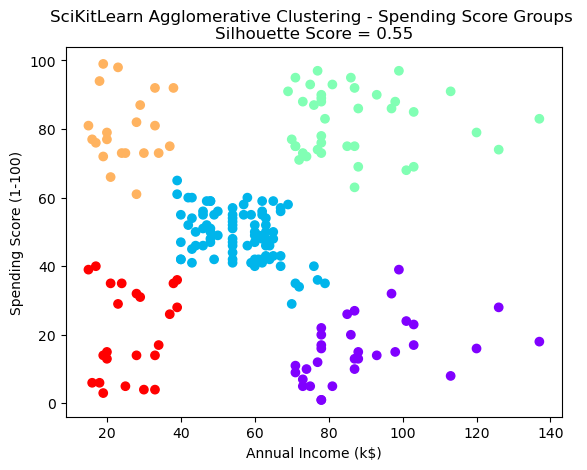

In [134]:
# SciKitLearn can generate Agglomerative Clustering, (i.e. a Dendogram), 
# but doesn't have the built-in code to plot it. The labels can be though!

from sklearn.cluster import AgglomerativeClustering
model7 = AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage = 'ward')
y7 = model7.fit_predict(x)

plt.scatter(x[:, 0], x[:, 1], c=y7, cmap="rainbow")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f"SciKitLearn Agglomerative Clustering - Spending Score Groups \nSilhouette Score = {round(silhouette_score(x, model7.labels_),2)}")

plt.show()

#### Dendograms:

If we want to visualize the Dendogram itself, need a new Library, called SciPy (https://scipy.org/) which allows us to determine and plot a Dendogram:

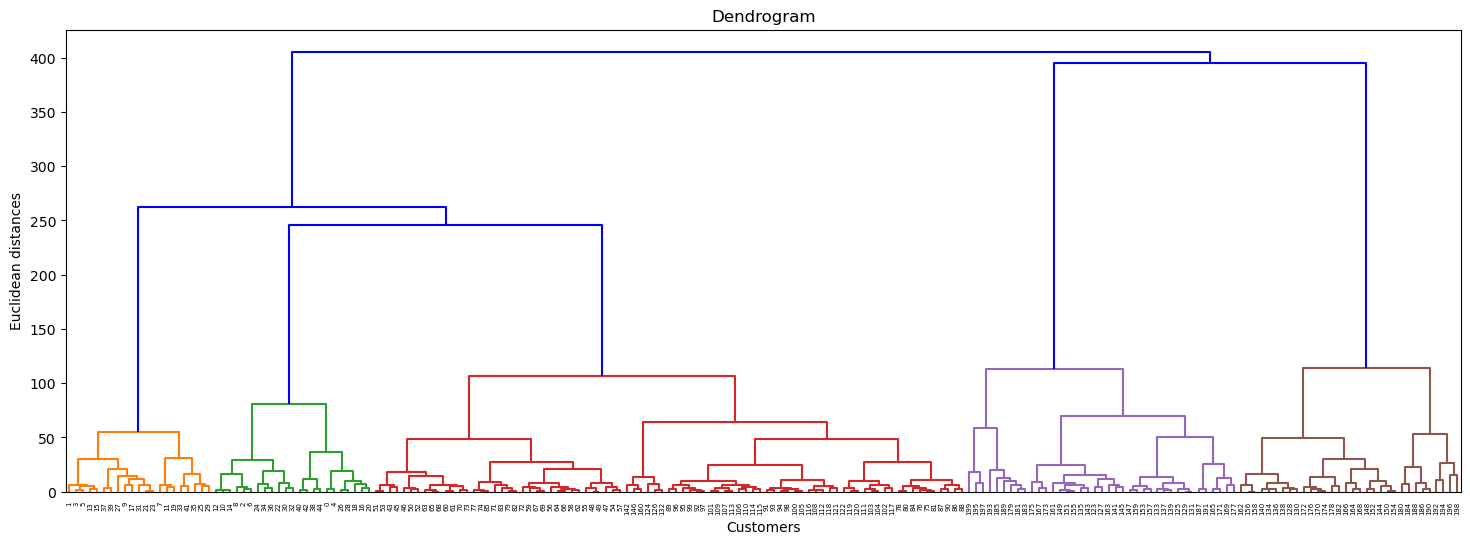

array([2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 3,
       2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 3, 4, 5, 4, 5, 4,
       3, 4, 5, 4, 5, 4, 5, 4, 5, 4, 3, 4, 5, 4, 3, 4, 5, 4, 5, 4, 5, 4,
       5, 4, 5, 4, 5, 4, 3, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4,
       5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4,
       5, 4], dtype=int32)

In [137]:
#SciPy Dendogram
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(18,6))
dendrogram = sch.dendrogram(sch.linkage(x, method ='ward'),
                                        color_threshold=200, 
                                        above_threshold_color='blue')
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

# Predict and plot the cluster labels from the SciPy Dendogram, like shown above:
from scipy.cluster.hierarchy import linkage, fcluster
max_d = 200
clusters_dendo = fcluster(sch.linkage(x, method ='ward'), max_d, criterion='distance')
clusters_dendo

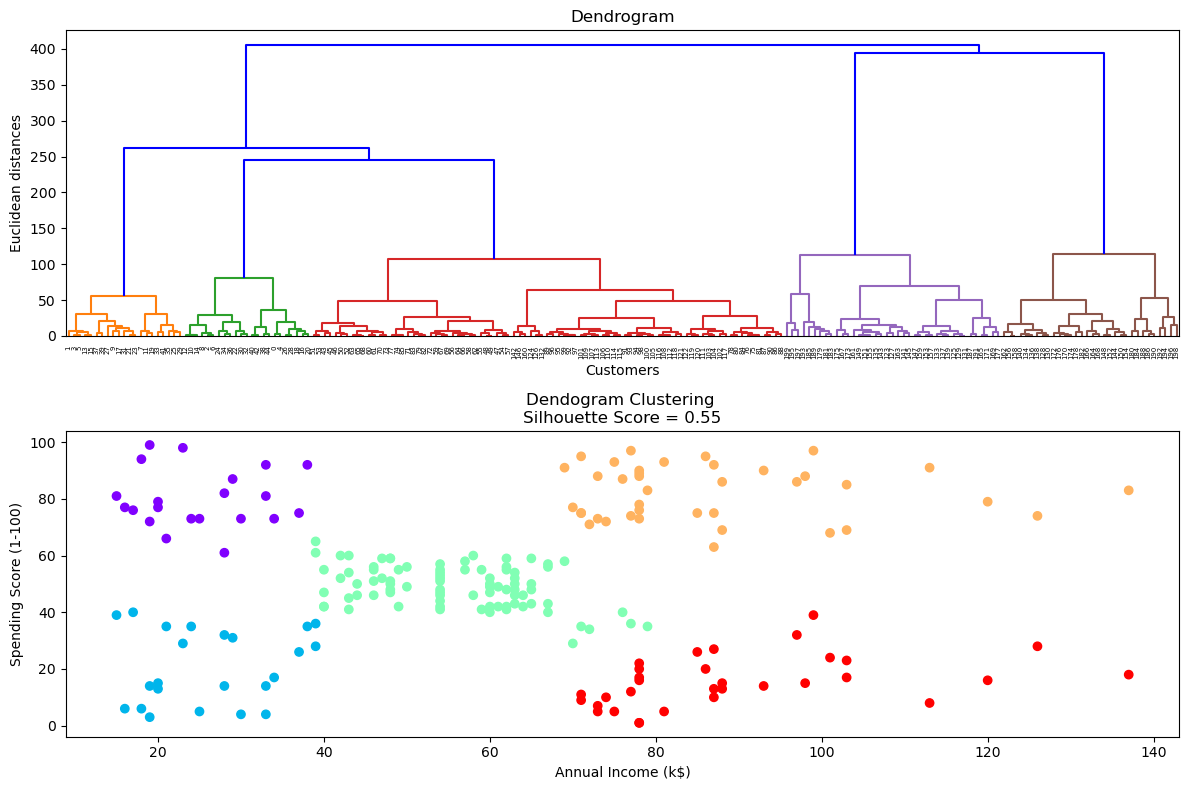

In [138]:
# View the SciPy Dendogram and scatterplot with it's labels together:
f, (ax1,ax2) = plt.subplots(nrows=2,ncols=1,figsize=(12,8))

ax1.set_title('Dendrogram')
ax1.set_xlabel('Customers')
ax1.set_ylabel('Euclidean distances')
sch.dendrogram(sch.linkage(x, method ='ward'),color_threshold=200, above_threshold_color='blue', ax = ax1) 

ax2.scatter(x[:, 0], x[:, 1], c=clusters_dendo, cmap="rainbow")
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')
ax2.set_title(f"Dendogram Clustering \nSilhouette Score = {round(silhouette_score(x, clusters_dendo),2)}")
plt.tight_layout()
plt.show()

### Mean Shift Clustering 

From Sklearn: Mean shift clustering aims to discover “blobs” in a smooth density of samples. It is a *centroid-based algorithm*, which works by updating candidates for centroids to be the mean of the points within a given region. These candidates are then filtered in a post-processing stage to eliminate near-duplicates to form the final set of centroids.

Source: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html

In [91]:
# We can use the estimate_bandwidth function to help use determine 
# an optimum bandwidth to use in the clustering algorithm. 
# We can also choose one for ourselves.

from sklearn.cluster import estimate_bandwidth
bandwidth = estimate_bandwidth(x, quantile=0.15 )
bandwidth

# quantile should be between [0, 1] - 
# 0.5 means that the median of all pairwise distances is used.
# The default is 0.3. The smaller the value, the shorter 
# the distance between points will be considered. i.e. A smaller window

22.29884826908017

In [93]:
from sklearn.cluster import MeanShift
model_meanshift = MeanShift(bandwidth = bandwidth)
model_meanshift.fit(x)

clusters_meanshift = model_meanshift.predict(x)

print("Unique CLusters:" ,np.unique(clusters_meanshift))
print("Number of Unique Clusters:",len(np.unique(clusters_meanshift)))

Unique CLusters: [0 1 2 3 4]
Number of Unique Clusters: 5


In [95]:
clusters_meanshift

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0, 3,
       4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int64)

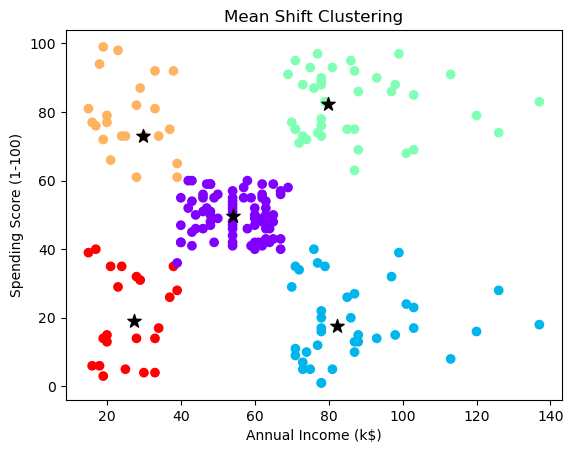

In [97]:
cluster_centers = model_meanshift.cluster_centers_

plt.scatter(x[:, 0], x[:, 1], c=clusters_meanshift, cmap="rainbow")
plt.scatter(model_meanshift.cluster_centers_[:, 0],
            model_meanshift.cluster_centers_[:, 1],
            color = 'black',
            marker = '*',
            s = 100)
plt.title('Mean Shift Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

In [ ]:
labels = model_meanshift.labels_
print("Silhouette Score:", round(silhouette_score(x, labels),2))

In [ ]:
f, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(15,6))

ax1.set_title('K Means = 5')
ax1.scatter(x[:,0],x[:,1],c=model5.labels_,cmap='rainbow')
ax1.scatter(model5.cluster_centers_[:, 0],
            model5.cluster_centers_[:, 1],
            color='black', marker='+', s=100)
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')


ax2.set_title('Mean Shift Clustering')
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')
ax2.scatter(x[:, 0], x[:, 1], c=clusters_meanshift, cmap="jet")
ax2.scatter(model_meanshift.cluster_centers_[:, 0],
            model_meanshift.cluster_centers_[:, 1],
            color = 'black', marker = '*', s = 100)

The K-Means and Mean Shift Clustering is very similar, but you can see a few differences. Which one would you recommend using for this problem?
<br><br>
Remember, Mean Shift is an expensive training model, and is best reserved for small to medium sized datasets. However, it does exceptionally well at discovering clusters if data is poorly separated and without having to determine the number of clusters beforehand.

## Save a model to file for delivarable

In [ ]:
# Save the model to disk
filename = 'spendingScoreK_Means.sav'
pickle.dump(model5, open(filename, 'wb'))

In [ ]:
# Load the model at some point in the future
spending1 = pickle.load(open('spendingScoreK_Means.sav','rb'))

In [ ]:
# Run the loaded model on some data.
# I didn't create and load new data here, so just using x again
spending1.predict(x)